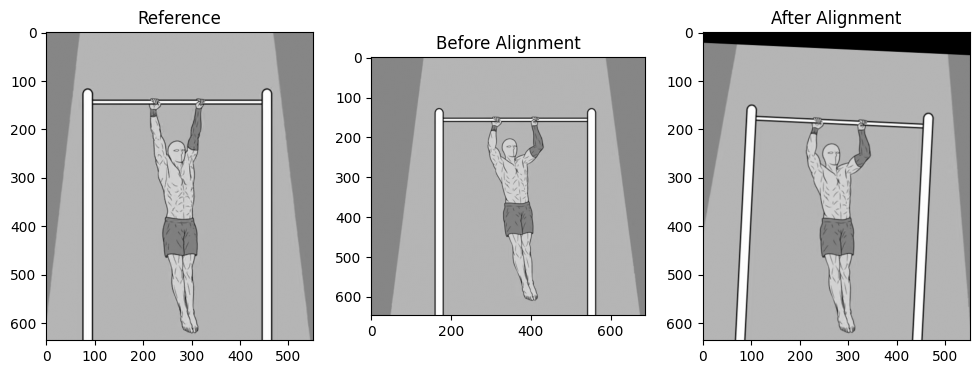

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('/content/im1.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/im2.png', cv2.IMREAD_GRAYSCALE)

# ORB detector
orb = cv2.ORB_create(5000)

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

# Brute Force Matcher
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# Sort matches by distance
matches = sorted(matches, key=lambda x: x.distance)

# Extract matched points
pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

# Estimate affine transform using RANSAC
M, inliers = cv2.estimateAffine2D(pts2, pts1, method=cv2.RANSAC)

# Warp image2 to align with image1
h, w = img1.shape
aligned = cv2.warpAffine(img2, M, (w, h))

# Show results
plt.figure(figsize=(12,4))
plt.subplot(131); plt.imshow(img1, cmap='gray'); plt.title("Reference")
plt.subplot(132); plt.imshow(img2, cmap='gray'); plt.title("Before Alignment")
plt.subplot(133); plt.imshow(aligned, cmap='gray'); plt.title("After Alignment")
plt.show()